In [2]:
import specsuite as ss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import glob
from astropy.table import QTable
from astropy.visualization import quantity_support
quantity_support();

from specutils import Spectrum
from astropy.nddata import StdDevUncertainty
from specutils import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import centroid, line_flux, fwhm, fwzi
from specutils.fitting import estimate_line_parameters, fit_lines
from astropy.modeling import models
from specutils.fitting import find_lines_derivative


# hide some annoying warnings (comment out if you're having bugs!)
import warnings
warnings.catch_warnings()
warnings.simplefilter('ignore')

from IPython.display import Image, display

In [2]:
# # Load into a DataFrame
# df = pd.read_csv('p_wavecal.csv')

# # Convert to a NumPy array
# p_wavecal = df.to_numpy()

# df = pd.read_csv('pdr_wavecal.csv')

# pdr_wavecal = df.to_numpy()

# df = pd.read_csv('paired_lines.csv')

# lines = df.to_numpy()

<span style="color:red">

This above is just for loading in the parts of Autumn's tool with the widget after doing the line matching. However, I haven't completed that yet and you'll see why later.

In [3]:
CAL_PATH = "UT260324/cals"
DATA_PATH = "UT260324/targets"
#DATA_REGION = (150, 825) # full image data region just for checking
DATA_REGION = (500, 800)
WAV_BOUNDS = (415 * u.nm, 705 * u.nm)

In [6]:
bias = ss.average_matching_files(
    path = CAL_PATH,
    tag = "bias",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_flat = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-quartz-0.73-ctr-blue", 
    instrument="KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_neon = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-neon-0.73-ctr-blue",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_krypton = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-krypton-0.73-ctr-blue",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_argon = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-argon-0.73-ctr-blue",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_helium = ss.average_matching_files(
    path = CAL_PATH,
    tag = "truss-helium-0.73-ctr-blue-0.73-ctr.0086",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) -bias
raw_darks = ss.average_matching_files(
    path = CAL_PATH,
    tag = "dark", 
    instrument="KOSMOS",
    crop_bds = DATA_REGION,
)

<span style="color:red">

You'll notice that some of the tags changed, this is becuase I didn't see initially that there were different arc lamps for the 2 different gratings (red vs blue). This should now correctly read and combine in the lamps we want. I also subtracted the bias here instead of down below for simplicity and since when you add them up in the arclamp it's technically adding 3 baias blah blah blah just use this.

Also also, I added in the helium truss arclamp.

In [7]:
raw_science_M61 = ss.average_matching_files(
    path = DATA_PATH,
    tag = "M61_300s",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_NCG = ss.average_matching_files(
    path = DATA_PATH,
    tag = "NCG6946_300s",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_Feige34 = ss.collect_images_array(
    path = DATA_PATH,
    tag = "feige34",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_HR7596 = ss.collect_images_array(
    path = DATA_PATH,
    tag = "HR7596",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)

In [8]:
arclamp = raw_arc_krypton
scienceM61 = raw_science_M61 - bias
scienceNCG = raw_science_NCG - bias
scienceFeige34 = raw_science_Feige34 - bias
scienceHR7596 = raw_science_HR7596 - bias

<span style="color:red">

Since bias is subtracted out above, only really need one of the arclamp variables. I am choosing to use the krypton one since it's wavelengths of light fall the most closely to where our data SHOULD be. This is a mistake I made before using the neon one. Could also use helium if you want.

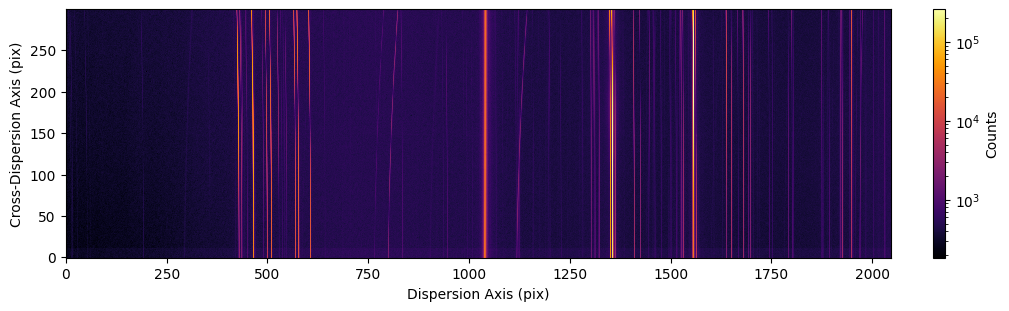

In [9]:
ss.plot_image(arclamp, norm="log")

In [10]:
# Identifies the pixel positions of line emissions
locs, _ = ss.find_cal_lines(
    image = arclamp,
    std_variation = 30,
    #debug = True,
)

# Models how line emissions are 'bent'
warp_model = ss.generate_warp_model(
    image = arclamp,
    guess = locs,
    #tolerance= 0.2,
    #debug = True,
)

<span style="color:red">

I changed the std for finding the line emissions sicne they seem to be dim using the 200 that is already in gives like 6 lines and I can visually tell that the ones it is choosing are real. Uncomment debug if you want to see the graphs and confirm.

In [11]:
backgrounds_m61 = ss.extract_background(
    images = raw_science_M61,
    warp_model = warp_model,
    mask_region = (125, 240),
    #debug = True,
)
calibrated_scienceM61 = raw_science_M61 - backgrounds_m61[0]

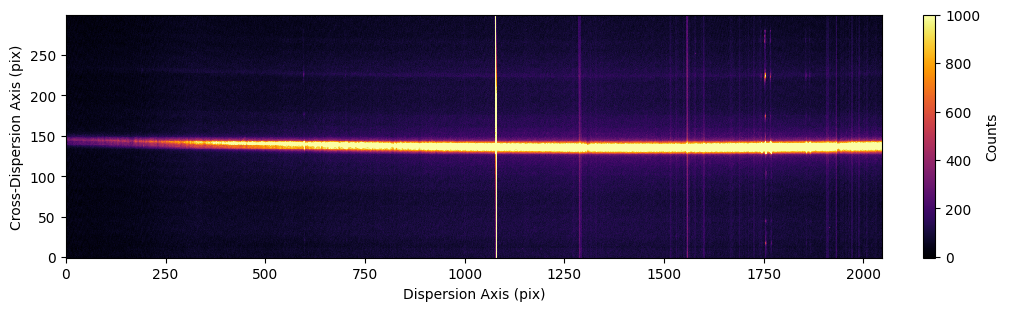

In [15]:
ss.plot_image(scienceM61, vmax=1e3)

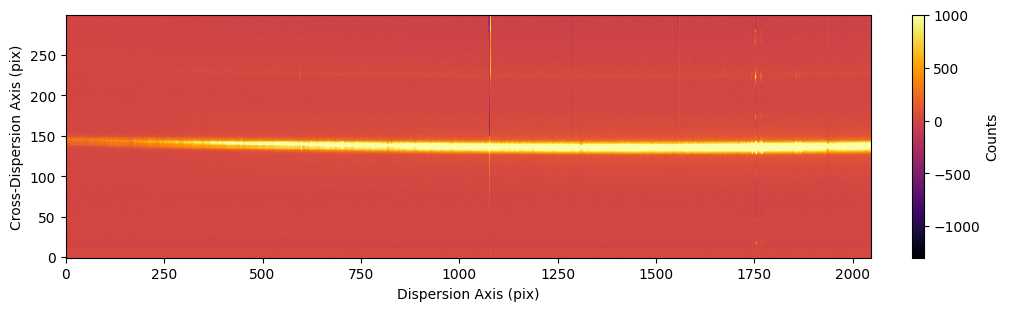

In [14]:
ss.plot_image(calibrated_scienceM61, vmax=1e3)

<span style="color:red">

There is still some remnant bits, but talking with Autumn they shouldn't matter since we only really care about the middle and spiral arms. If you think you can fix/make it better go for it :P

In [16]:
M61_flux = np.sum(calibrated_scienceM61, axis = 0)

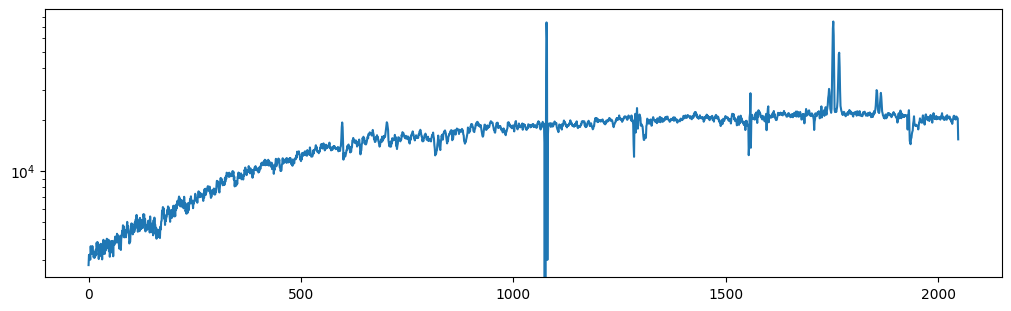

In [17]:
plt.plot(M61_flux)
plt.yscale("log")

<span style="color:red">

Flux values that we worked with Autumn with.

In [18]:
# Re-runs background extraction and collects additional returns
returned_data_m61 = ss.extract_background(
    images = raw_science_M61,
    warp_model = warp_model,
    mask_region = (125,240),
    return_spectrum = True,
)

# Unpacks returned data into separate arrays
_m61, background_effpix_m61, background_flux_m61, effpix_map_m61 = returned_data_m61

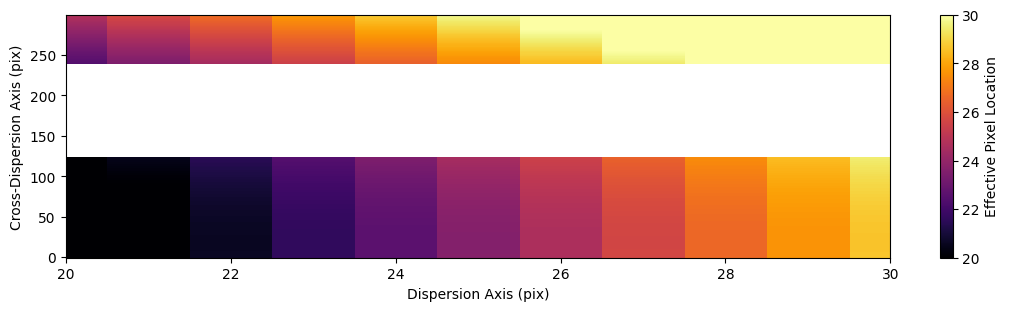

In [19]:
# Plots a small region of the effective pixel map
ss.plot_image(
    effpix_map_m61,
    cbar_label = "Effective Pixel Location",
    xlim = (20, 30),
    vmin = 20,
    vmax = 30,
)

<span style="color:red">

Autumn describes the usefullness of these pixel maps in the document, but I do not understand it yet and want to ask her about it more. So for now they are just here to be here.

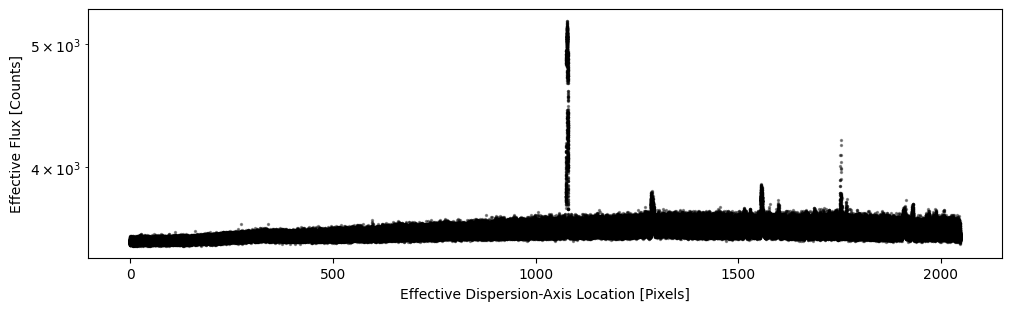

In [20]:
# Plots the supersampled background spectra
plt.scatter(
    returned_data_m61[1],
    returned_data_m61[2][0],
    color = "black",
    alpha = 0.4,
    s = 2,
)

# Formats the labels and scaling 
plt.xlabel("Effective Dispersion-Axis Location [Pixels]")
plt.ylabel("Effective Flux [Counts]")
plt.yscale("log")
plt.show()

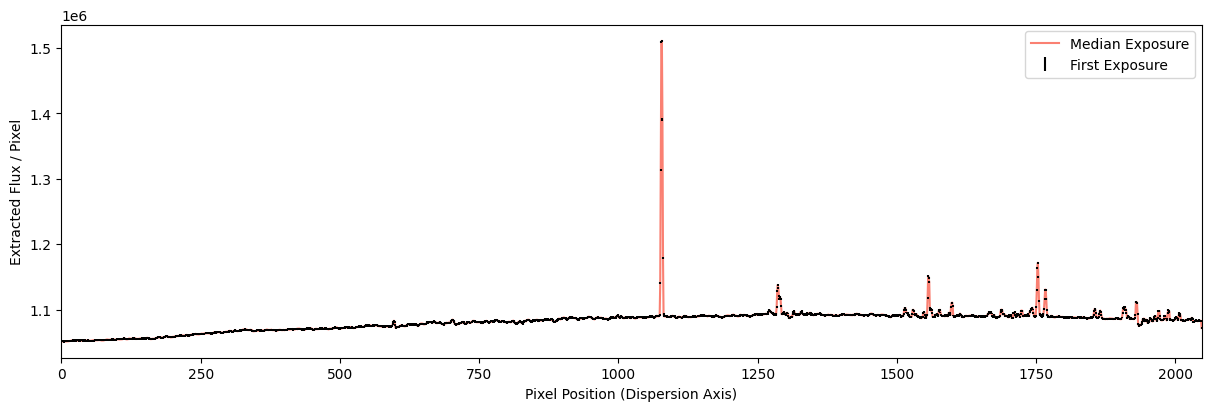

In [21]:
optimal_flux_m61, optimal_err_m61 = ss.horne_extraction(
    images = raw_science_M61,
    backgrounds = backgrounds_m61[0],
    profile = "moffat",
    RN = 6.0,
    debug = True,
)

In [22]:
backgrounds_NGC = ss.extract_background(
    images = raw_science_NCG,
    warp_model = warp_model,
    mask_region = (100, 220),
    #debug = True,
)
calibrated_scienceNCG = raw_science_NCG - backgrounds_NGC[0]

In [23]:
# Re-runs background extraction and collects additional returns
returned_data_NGC = ss.extract_background(
    images = raw_science_NCG,
    warp_model = warp_model,
    mask_region = (100,220),
    return_spectrum = True,
)

# Unpacks returned data into separate arrays
_NGC, background_effpix_NGC, background_flux_NGC, effpix_map_NGC = returned_data_NGC

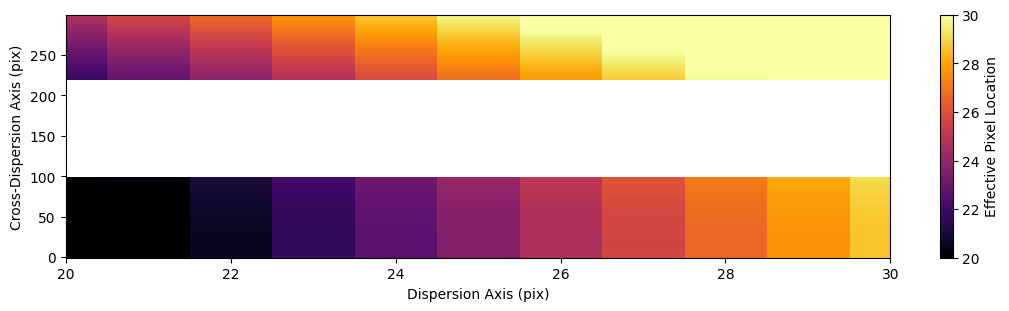

In [24]:
# Plots a small region of the effective pixel map
ss.plot_image(
    effpix_map_NGC,
    cbar_label = "Effective Pixel Location",
    xlim = (20, 30),
    vmin = 20,
    vmax = 30,
)

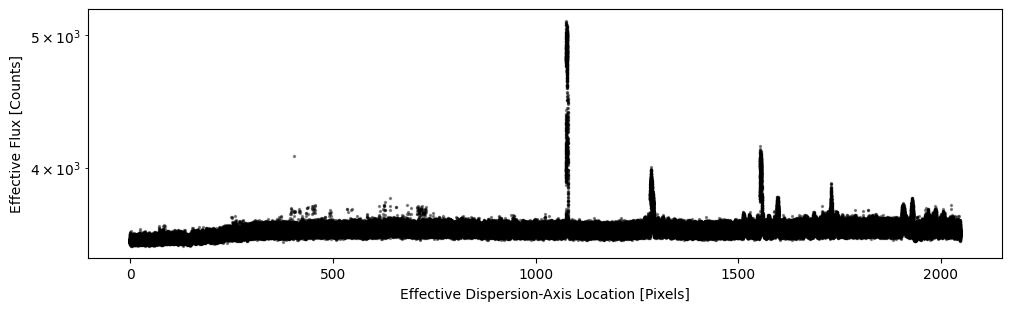

In [25]:
# Plots the supersampled background spectra
plt.scatter(
    returned_data_NGC[1],
    returned_data_NGC[2][0],
    color = "black",
    alpha = 0.4,
    s = 2,
)

# Formats the labels and scaling
plt.xlabel("Effective Dispersion-Axis Location [Pixels]")
plt.ylabel("Effective Flux [Counts]")
plt.yscale("log")
plt.show()

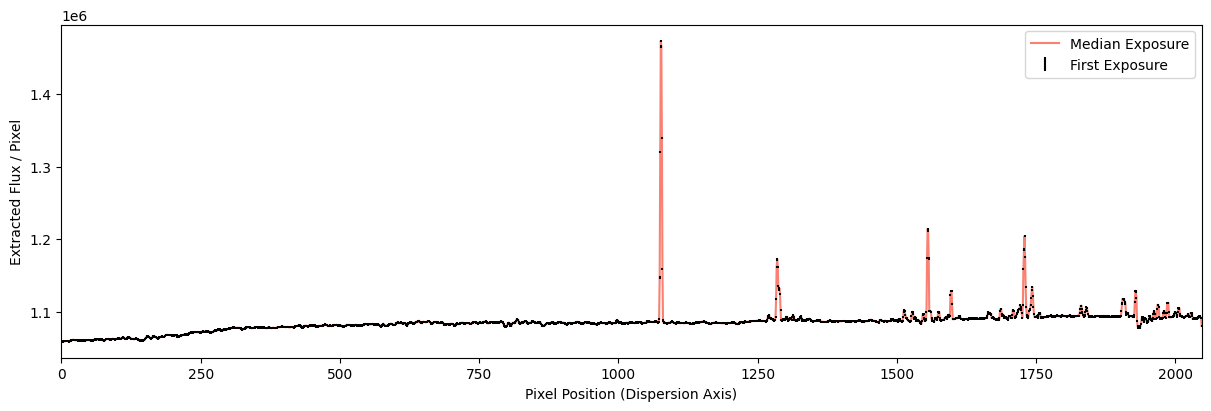

In [26]:
optimal_flux_NGC, optimal_err_NGC = ss.horne_extraction(
    images = raw_science_NCG,
    backgrounds = backgrounds_NGC[0], 
    profile = "moffat",
    RN = 6.0,
    debug = True,
)

In [27]:
arclamp_lines, _ = ss.find_cal_lines(arclamp, std_variation=30)

In [26]:
# Krypton (Kr) emission lines between 4150 and 7050 Å
# Source: NIST Handbook of Basic Atomic Spectroscopic Data
# https://physics.nist.gov/PhysRefData/Handbook/Tables/kryptontable2_a.htm
# Wavelengths in Angstroms (air), sorted in ascending order

kr_lines = [
    4250.580,   # Kr II
    4273.9694,  # Kr I
    4282.9674,  # Kr I
    4292.923,   # Kr II
    4300.49,    # Kr II
    4317.81,    # Kr II
    4318.5513,  # Kr I
    4319.5794,  # Kr I
    4322.98,    # Kr II
    4351.3597,  # Kr I
    4355.477,   # Kr II  *** P (persistent) ***
    4362.6416,  # Kr I
    4369.69,    # Kr II
    4376.1216,  # Kr I
    4386.54,    # Kr II
    4399.9663,  # Kr I
    4425.1901,  # Kr I
    4431.685,   # Kr II
    4436.812,   # Kr II
    4453.9175,  # Kr I
    4463.6900,  # Kr I
    4475.014,   # Kr II
    4489.88,    # Kr II
    4502.3543,  # Kr I
    4523.14,    # Kr II
    4556.61,    # Kr II
    4577.209,   # Kr II
    4582.978,   # Kr II
    4592.80,    # Kr II
    4615.292,   # Kr II
    4619.166,   # Kr II  *** P ***
    4633.885,   # Kr II
    4658.876,   # Kr II  *** P ***
    4680.406,   # Kr II
    4691.301,   # Kr II
    4694.360,   # Kr II
    4739.002,   # Kr II  *** P ***
    4762.435,   # Kr II
    4765.744,   # Kr II  *** P ***
    4811.76,    # Kr II
    4825.18,    # Kr II
    4832.077,   # Kr II  *** P ***
    4846.612,   # Kr II  *** P ***
    4857.20,    # Kr II
    4945.59,    # Kr II
    5022.40,    # Kr II
    5086.52,    # Kr II
    5125.73,    # Kr II
    5208.32,    # Kr II
    5308.66,    # Kr II
    5333.41,    # Kr II
    5468.17,    # Kr II
    5562.2253,  # Kr I
    5570.2894,  # Kr I   *** P ***
    5580.3873,  # Kr I
    5649.5618,  # Kr I
    5681.89,    # Kr II
    5690.35,    # Kr II
    5832.8566,  # Kr I
    5870.9160,  # Kr I   *** P ***
    5992.22,    # Kr II
    5993.8502,  # Kr I
    6056.1263,  # Kr I
    6420.18,    # Kr II
    6421.0270,  # Kr I
    6456.2889,  # Kr I
    6570.07,    # Kr II
    6699.2296,  # Kr I
    6904.6788,  # Kr I
]

<span style="color:red">

^ List of all possible lines

In [27]:
kr_lines = [
    # 6420.18,    # Kr II  intensity 100
    # 5992.22,    # Kr II  intensity 70
    # 5870.9160,  # Kr I   intensity 500 *** P ***
    # 5681.89,    # Kr II  intensity 130
    # 5570.2894,  # Kr I   intensity 300 *** P ***
    # 5333.41,    # Kr II  intensity 150
    # 5208.32,    # Kr II  intensity 150
    # 5125.73,    # Kr II  intensity 130 h
    # 4946.59,    # Kr II  intensity 100
    # 4846.612,   # Kr II  intensity 250 *** P ***
    # 4832.077,   # Kr II  intensity 250 *** P ***
    # 4765.744,   # Kr II  intensity 300 *** P ***
    # 4739.002,   # Kr II  intensity 1000 *** P ***
    # 4658.876,   # Kr II  intensity 700 *** P ***
    # 4633.885,   # Kr II  intensity 250
    # 4619.166,   # Kr II  intensity 300 *** P ***
    # 4577.209,   # Kr II  intensity 250
    # 4475.014,   # Kr II  intensity 250
    # 4463.6900,  # Kr I   intensity 130
    # 4436.812,   # Kr II  intensity 200
    # 4431.685,   # Kr II  intensity 150
    # 4376.1216,  # Kr I   intensity 130
    # 4355.477,   # Kr II  intensity 1000 *** P ***
    # 4319.5794,  # Kr I   intensity 150
    # 4317.81,    # Kr II  intensity 150 h
    # 4292.923,   # Kr II  intensity 200
    # 4273.9694,  # Kr I   intensity 150
]

<span style="color:red">

^ Cut down version of the lines that I am not actively using.

In [28]:
kr_lines = [
    4250.580,   # Kr II
    4273.9694,  # Kr I
    4282.9674,  # Kr I
    4292.923,   # Kr II
    4300.49,    # Kr II
    4317.81,    # Kr II
    4318.5513,  # Kr I
    4319.5794,  # Kr I
    4322.98,    # Kr II
    4351.3597,  # Kr I
    4355.477,   # Kr II  *** P (persistent) ***
    4362.6416,  # Kr I
    4369.69,    # Kr II
    4376.1216,  # Kr I
    4386.54,    # Kr II
    4399.9663,  # Kr I
    4425.1901,  # Kr I
    4431.685,   # Kr II
    4436.812,   # Kr II
    4453.9175,  # Kr I
    4463.6900,  # Kr I
    4475.014,   # Kr II
    4489.88,    # Kr II
    4502.3543,  # Kr I
    4523.14,    # Kr II
    4556.61,    # Kr II
    4577.209,   # Kr II
    4582.978,   # Kr II
    4592.80,    # Kr II
    4615.292,   # Kr II
    4619.166,   # Kr II  *** P ***
    4633.885,   # Kr II
    4658.876,   # Kr II  *** P ***
    4680.406,   # Kr II
    4691.301,   # Kr II
    4694.360,   # Kr II
    4739.002,   # Kr II  *** P ***
    4762.435,   # Kr II
    4765.744,   # Kr II  *** P ***
    4811.76,    # Kr II
    4825.18,    # Kr II
    4832.077,   # Kr II  *** P ***
    4846.612,   # Kr II  *** P ***
    4857.20,    # Kr II
    4945.59,    # Kr II
    5022.40,    # Kr II
    5086.52,    # Kr II
    5125.73,    # Kr II
    5208.32,    # Kr II
    5308.66,    # Kr II
    5333.41,    # Kr II
    5468.17,    # Kr II
    5562.2253,  # Kr I
    5570.2894,  # Kr I   *** P ***
    5580.3873,  # Kr I
    5649.5618,  # Kr I
    5681.89,    # Kr II
    5690.35,    # Kr II
    5832.8566,  # Kr I
    5870.9160,  # Kr I   *** P ***
    5992.22,    # Kr II
    5993.8502,  # Kr I
    6056.1263,  # Kr I
    6420.18,    # Kr II
    6421.0270,  # Kr I
    6456.2889,  # Kr I
    6570.07,    # Kr II
    6699.2296,  # Kr I
    6904.6788,  # Kr I
]

<span style="color:red">

^ List with some of the very low intensity lines taken out since they are very likely to not be visible

In [29]:
# known_lines = [
#     5852.49, 5881.90, 5944.83, 6030.00, 6096.16, 6143.06, 6266.50, 6334.43, 6382.99, 6402.25,
#     6506.53, 6598.95, 6678.28, 6717.04, 6929.47, 6032.41, 7173.94, 7245.17, 7438.90, 7488.87,
#     8300.36, 8377.61, 8495.36, 8654.38, 8780.62, 8853.87,
# ]

<span style="color:red">

This is what I WAS using... which is Autumn for Neon. But as you can see the wavelengths compared to what WE want to be looking at is too high. This is why my graph and the scaling had been all fucked up.. mb

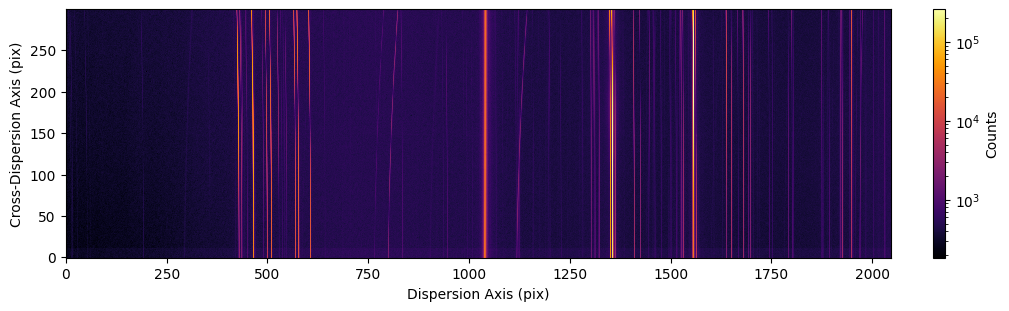

In [30]:
ss.plot_image(arclamp, norm="log")

In [ ]:
wavecal_widget = ss.WavecalWidget(
    upper_lines = arclamp_lines,
    lower_lines = kr_lines,
)

# wavecal_widget.activate_widget()   #uncomment to interact with the widget

In [32]:
paired_lines = wavecal_widget.final_lines # List of all paired lines
# p_wavecal = wavecal_widget.p # The final np.polynomial
# pdr_wavecal = wavecal_widget.pdr # The final derivative of np.polynomial

In [33]:
pixel = np.array(np.arange(2048))

In [34]:
df = pd.DataFrame(paired_lines)
df.to_csv('paired_lines.csv', index=False)

In [35]:
# coeff = np.polyfit(paired_lines[1], paired_lines[0], deg=3)
# p_wavecal = np.poly1d(coeff)

In [36]:
# wavelengths = p_wavecal(pixel)

In [37]:
# wavelengths

<span style="color:red">

Uncomment stuff above after you use widget to save the paired lines list. Then using the coeff and p_wavecal to get our polynomial. Then wavelengths stretches/fits that polynomial wavelengths onto the pixels that we have on our image (over the 2048 on the x axis)

In [41]:
known_emission_lines = {
    "Hα":        6562.80,
    "[N II]":    6548.05,
    "[N II]":    6583.45,
    "[O II]":    7318.92,
    "[O II]":    7319.99,
    "[HB]": 4861,
    "[O III]": 4959, 
    "[O III]": 5007,
}

In [42]:
flat_M61 = ss.flatfield_correction(scienceM61, raw_flat)

In [43]:
print(np.shape(raw_science_NCG))

(300, 2048)


In [44]:
#ss.plot_image(flat_M61)

In [45]:
# import ASDtools as asdt
# lines = asdt.NIST_lines(["He I", "He II"], lower_wavelength=3000*u.AA, upper_wavelength=9000*u.AA)
# lines.df

In [46]:
## START OF ZACK's THINGS

<span style="color:red">

START OF ZACK'S CODING. ALL OF THIS IS JUST TESTING AND A LOT IS PURPOSING DOING THINGS WRONG TO MAKE IT EASY TO VIEW AND TEST. ALLLLLLLL UNFINISHED AND STILL TESTING. CAREFUL :p

In [86]:
optimal_flux_m61 = optimal_flux_m61 - 1.1e6 + 12553.751

In [107]:
optimal_flux_m61 = optimal_flux_m61 - 10000

In [108]:
spec = QTable(dict(
    wavelength_pixel=np.arange(scienceM61.shape[1]) * u.pixel,
    flux=np.squeeze(optimal_flux_m61) / u.pixel,
    uncertainty=np.squeeze(optimal_err_m61) / u.pixel,
))

In [109]:
spectrum = Spectrum(spectral_axis=spec['wavelength_pixel'], 
                    flux=spec['flux'],
                    uncertainty=StdDevUncertainty(spec['uncertainty']))

spectrum

<Spectrum(flux=[-46191.66348672092 ... -25780.145683692932] 1 / pix (shape=(2048,), mean=-15347.26198 1 / pix); spectral_axis=<SpectralAxis [0.000e+00 1.000e+00 2.000e+00 ... 2.045e+03 2.046e+03 2.047e+03] pix> (length=2048); uncertainty=StdDevUncertainty)>

In [110]:
def plot_spectrum(spectrum, **kw):
    '''
    Make a plot of a specutils.Spectrum object.

    Parameters 
    ----------
    spectrum : specutils.Spectrum
        The main input should be a spectrum stored 
        as a `specutils` object, with `.spectral_axis`
        and `.flux` attributes attached.
    **kw : dict 
        All other keywords will be passed into the 
        `plt.step` plotting function. 
    '''

    # extract the arrays we need
    x = spectrum.spectral_axis
    flux = spectrum.flux
    uncertainty = spectrum.uncertainty.quantity

    # plot the spectrum
    plt.step(x, flux, where='mid', **kw)
    plt.errorbar(x, flux, uncertainty, linewidth=0, elinewidth=1, color='gray', alpha=0.5)

    # add some labels
    plt.xlabel(f'Wavelength ({x.unit.to_string(format="latex_inline")})')
    plt.ylabel('Flux (photons s$^-1$ pixel$^-1$)')

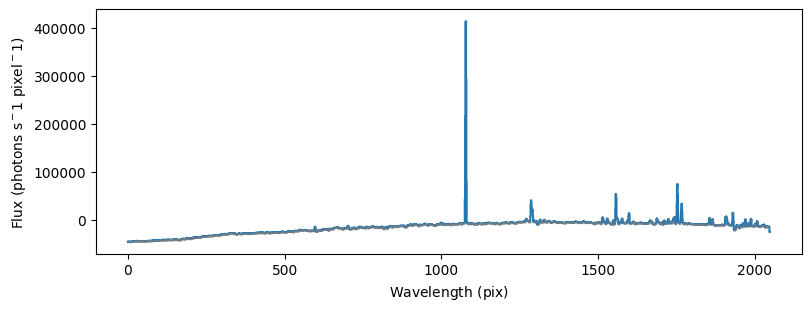

In [111]:
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum)

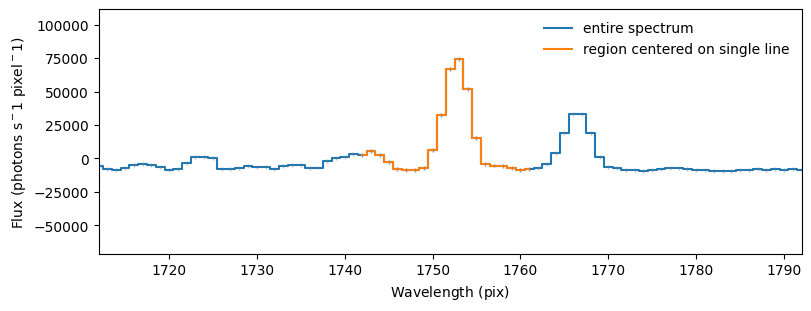

In [126]:
# define the pixels on which we want to focus
line_pixel = 1752*u.pixel
window = 10*u.pixel

# make a tiny sub-spsectrum from that region
sub_region = SpectralRegion(line_pixel - window, line_pixel + window)
sub_spectrum = extract_region(spectrum, sub_region)

# plot the region over the overall spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum, label='entire spectrum')
plot_spectrum(sub_spectrum, label='region centered on single line')
plt.legend(frameon=False)
plt.xlim(line_pixel - window*4, line_pixel + window*4)
plt.ylim(None, np.max(sub_spectrum.flux)*1.5);

In [127]:
sub_spectrum.spectral_axis

<SpectralAxis [1742., 1743., 1744., 1745., 1746., 1747., 1748., 1749., 1750., 1751.,
   1752., 1753., 1754., 1755., 1756., 1757., 1758., 1759., 1760., 1761.] pix>

In [128]:
sub_spectrum.flux

<Quantity [ 2840.61784009,  5398.07167967,  2640.10675454, -2596.91671206,
           -7839.43291787, -8350.53936065, -8908.88809272, -7265.47817891,
            6071.58699941, 32823.765993  , 66837.9772441 , 74232.51645815,
           51909.94300054, 15425.35162294, -4207.86261339, -5258.13269942,
           -5273.49020657, -7321.64628392, -8627.48158437, -7520.354252  ] 1 / pix>

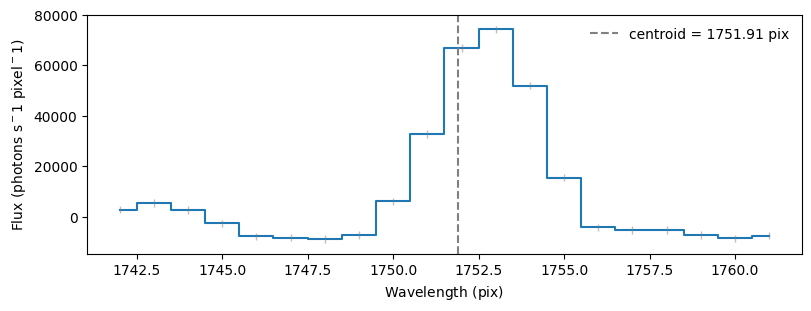

In [129]:
# calculate the flux-weight centroid of the region sub-spectrum
this_line_centroid = centroid(sub_spectrum)

# plot the centroid
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')
plt.legend(frameon=False);

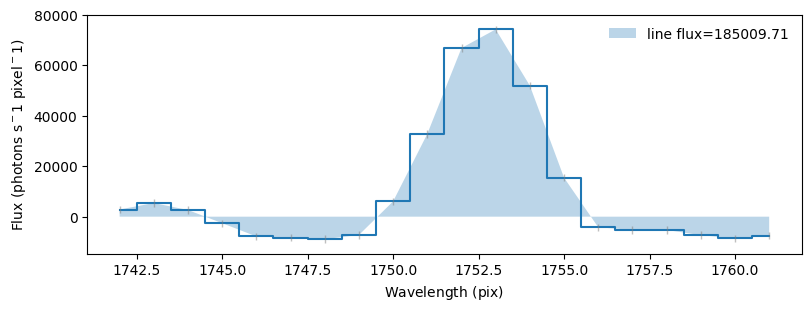

In [130]:
# calculate the line flux
this_line_flux = line_flux(sub_spectrum)

# plot the line flux
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'line flux={this_line_flux:.2f}')
plt.legend(frameon=False);

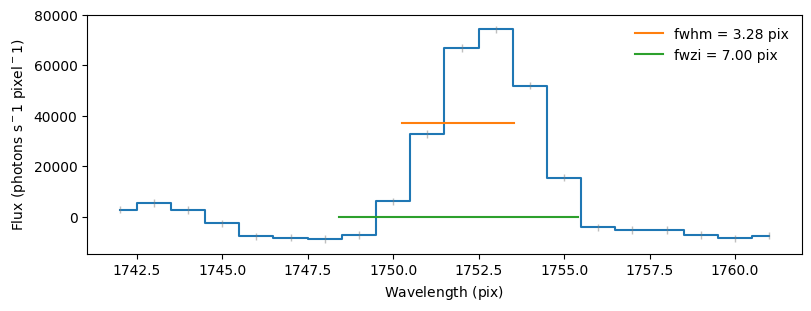

In [131]:
# calculate various types of line width
this_line_fwhm = fwhm(sub_spectrum)
this_line_fwzi = fwzi(sub_spectrum)

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")

# draw a line for the FWZI
x = this_line_centroid + [-0.5,0.5]*this_line_fwzi
y = np.zeros(2)
plt.plot(x, y, label=f"fwzi = {this_line_fwzi:.2f}")

plt.legend(frameon=False);

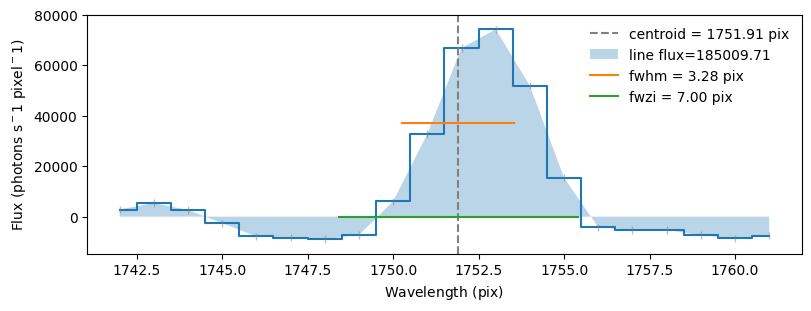

In [132]:
# calculate the flux-weight centroid of the region sub-spectrum
this_line_centroid = centroid(sub_spectrum)

# calculate the line flux
this_line_flux = line_flux(sub_spectrum)

# calculate various types of line width
this_line_fwhm = fwhm(sub_spectrum)
this_line_fwzi = fwzi(sub_spectrum)

# plot the centroid
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'line flux={this_line_flux:.2f}')

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")

# draw a line for the FWZI
x = this_line_centroid + [-0.5,0.5]*this_line_fwzi
y = np.zeros(2)
plt.plot(x, y, label=f"fwzi = {this_line_fwzi:.2f}")

plt.legend(frameon=False);

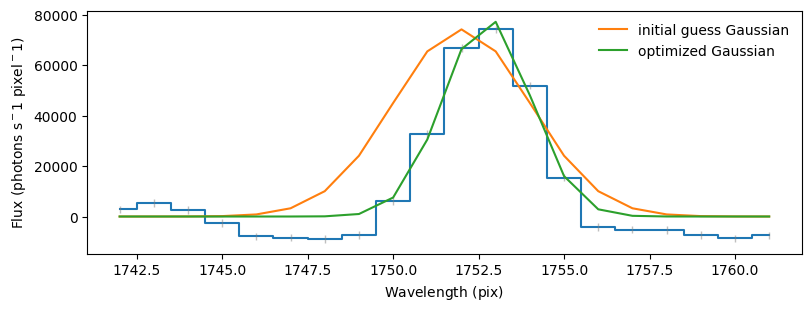

In [133]:
# define an initial guess for the Gaussian line model
gaussian_initial_guess = models.Gaussian1D(mean=line_pixel, stddev=2*u.pix, amplitude=np.max(sub_spectrum.flux))

# optimize the parameters of that initial guess
gaussian_optimized = fit_lines(sub_spectrum, gaussian_initial_guess)

# plot the spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# plot the initial guess model
plt.plot(sub_spectrum.spectral_axis, gaussian_initial_guess(sub_spectrum.spectral_axis), label=f'initial guess Gaussian')

# plot the optimized model 
plt.plot(sub_spectrum.spectral_axis, gaussian_optimized(sub_spectrum.spectral_axis), label=f'optimized Gaussian')
plt.legend(frameon=False);

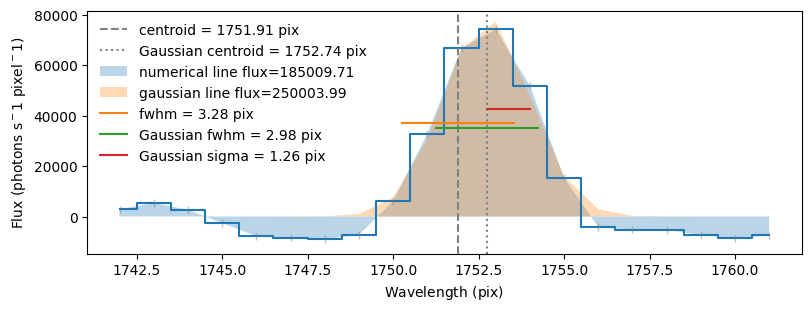

In [134]:
# plot the spectrum
plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(sub_spectrum)

# extract the optimized model parameters
gaussian_line_centroid = gaussian_optimized.mean.quantity
gaussian_line_sigma = gaussian_optimized.stddev.quantity
gaussian_line_amplitude = gaussian_optimized.amplitude.quantity

# calculate integrated line flux from the integral of a Gaussian
gaussian_line_flux = gaussian_line_amplitude*np.sqrt(2*np.pi*gaussian_line_sigma**2)
gaussian_line_fwhm = gaussian_optimized.fwhm

# plot the centroid
plt.axvline(this_line_centroid, color='gray', linestyle='--', label=f'centroid = {this_line_centroid:.2f}')
plt.axvline(gaussian_line_centroid, color='gray', linestyle=':', label=f'Gaussian centroid = {gaussian_line_centroid:.2f}')

# draw the area being integrated
plt.fill_between(sub_spectrum.spectral_axis, sub_spectrum.flux, alpha=0.3, label=f'numerical line flux={this_line_flux:.2f}')
plt.fill_between(sub_spectrum.spectral_axis, gaussian_optimized(sub_spectrum.spectral_axis), alpha=0.3, label=f'gaussian line flux={gaussian_line_flux:.2f}')

# draw a line for the FWHM
x = this_line_centroid + [-0.5,0.5]*this_line_fwhm
y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y, label=f"fwhm = {this_line_fwhm:.2f}")
x = gaussian_line_centroid + [-0.5,0.5]*gaussian_line_fwhm
plt.plot(x, y*.95, label=f"Gaussian fwhm = {gaussian_line_fwhm:.2f}")

# draw a line for the FWHM
x = gaussian_line_centroid + [0,1]*gaussian_line_sigma
y = np.exp(-0.5)*np.max(sub_spectrum.flux)*np.ones(2)
plt.plot(x, y*.95, label=f"Gaussian sigma = {gaussian_line_sigma:.2f}")

plt.legend(frameon=False);